In [1]:
%matplotlib inline
from matplotlib import style
style.use('fivethirtyeight')
import matplotlib.pyplot as plt

In [2]:
import numpy as np
import pandas as pd
import datetime as dt

# Reflect Tables into SQLAlchemy ORM

In [3]:
# Python SQL toolkit and Object Relational Mapper
import sqlalchemy
from sqlalchemy.ext.automap import automap_base
from sqlalchemy.orm import Session
from sqlalchemy import create_engine, func

In [4]:
# create engine to hawaii.sqlite
# Create the engine with the correct SQLite syntax

engine = create_engine("sqlite:///Resources/hawaii.sqlite")

In [5]:
# Correct engine creation for SQLite with multiple threads allowed
engine = create_engine("sqlite:///Resources/hawaii.sqlite", connect_args={"check_same_thread": False})

# Reflect the existing database into a new model
Base = automap_base()

# Use the metadata reflect method to reflect the tables from the database
Base.metadata.reflect(engine)

# Prepare the Base for usage
Base.prepare()

In [6]:
# View all of the classes that automap found
# View all classes that were found
Base.classes.keys()

['measurement', 'station']

In [7]:
3. # Save references to each table
# Save references to each table
Measurement = Base.classes.measurement
Station = Base.classes.station


In [8]:
4. # Create our session (link) from Python to the DB
# Create a session to link Python to the database
session = Session(engine)

# Exploratory Precipitation Analysis

In [9]:
5. # Find the most recent date in the data set.
# Find the most recent date in the data set
most_recent_date = session.query(func.max(Measurement.date)).first()[0]
print(f"Most Recent Date: {most_recent_date}")


Most Recent Date: 2017-08-23


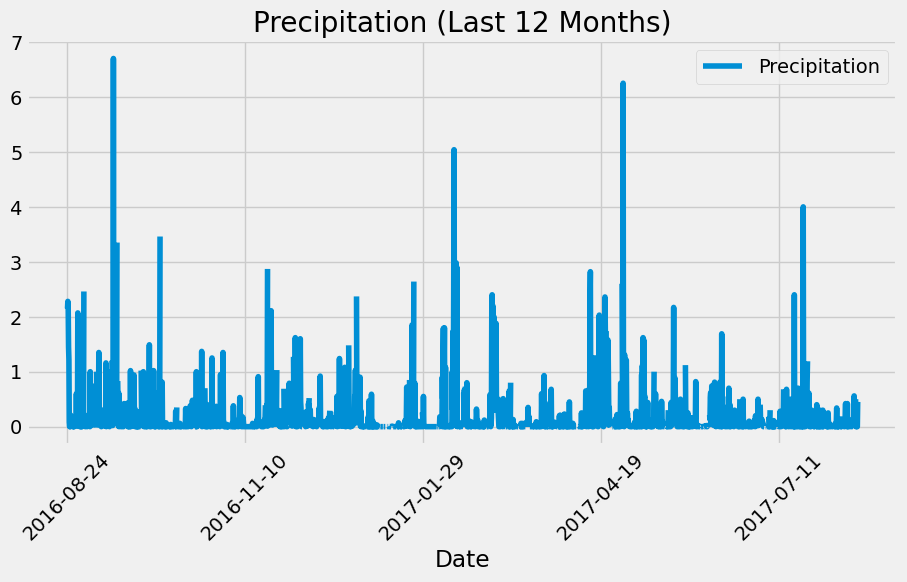

In [10]:
# Calculate the date one year from the last date in the dataset
one_year_ago = dt.datetime.strptime(most_recent_date, "%Y-%m-%d") - dt.timedelta(days=365)

# Perform a query to retrieve the date and precipitation scores from the last 12 months
precip_data = session.query(Measurement.date, Measurement.prcp).filter(Measurement.date >= one_year_ago).all()

# Save the query results as a Pandas DataFrame
precip_df = pd.DataFrame(precip_data, columns=['Date', 'Precipitation'])

# Sort the DataFrame by date
precip_df = precip_df.sort_values('Date')

# Plot the data using Pandas plotting with Matplotlib
precip_df.plot(x='Date', y='Precipitation', figsize=(10, 5), title="Precipitation (Last 12 Months)")
plt.xticks(rotation=45)
plt.show()

In [11]:
7. # Use Pandas to calculate the summary statistics for the precipitation data
# Use Pandas to calculate the summary statistics for the precipitation data
precip_df.describe()



,Precipitation
count,2015.000000
mean,0.176462
std,0.460288
min,0.000000
25%,0.000000
50%,0.020000
75%,0.130000
max,6.700000


# Exploratory Station Analysis

In [12]:
8. # Design a query to calculate the total number of stations in the dataset
# Query to calculate the total number of stations in the dataset
total_stations = session.query(func.count(Station.station)).first()[0]
print(f"Total Stations: {total_stations}")

Total Stations: 9


In [16]:
9. # Design a query to find the most active stations (i.e. which stations have the most rows?)
# List the stations and their counts in descending order.
# Query to find the most active stations (i.e., which stations have the most rows)
active_stations = session.query(Measurement.station, func.count(Measurement.station)).\
    group_by(Measurement.station).\
    order_by(func.count(Measurement.station).desc()).all()

# Print the stations and their counts
active_stations

[('USC00519281', 2772),
 ('USC00519397', 2724),
 ('USC00513117', 2709),
 ('USC00519523', 2669),
 ('USC00516128', 2612),
 ('USC00514830', 2202),
 ('USC00511918', 1979),
 ('USC00517948', 1372),
 ('USC00518838', 511)]

In [17]:
10. # Using the most active station id from the previous query, calculate the lowest, highest, and average temperature.
# Get the most active station ID
most_active_station = active_stations[0][0]
print(f"Most Active Station ID: {most_active_station}")

# Query to calculate the lowest, highest, and average temperature for the most active station
temp_stats = session.query(
    func.min(Measurement.tobs),
    func.avg(Measurement.tobs),
    func.max(Measurement.tobs)
).filter(Measurement.station == most_active_station).all()

print(f"Temperature Stats for Station {most_active_station}: {temp_stats}")


Most Active Station ID: USC00519281
Temperature Stats for Station USC00519281: [(54.0, 71.66378066378067, 85.0)]


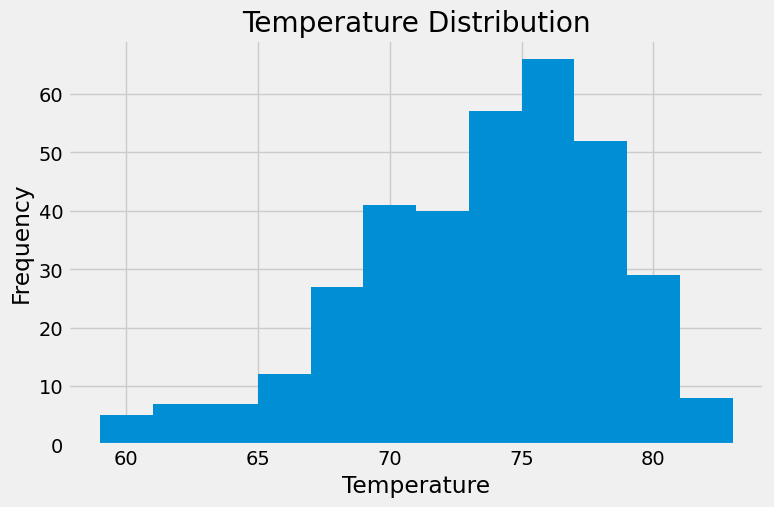

In [18]:
11. # Using the most active station id
# Query the last 12 months of temperature observation data for this station and plot the results as a histogram
# Query the last 12 months of temperature observation data for the most active station
temp_data = session.query(Measurement.date, Measurement.tobs).\
    filter(Measurement.station == most_active_station).\
    filter(Measurement.date >= one_year_ago).all()

# Save the query results as a DataFrame
temp_df = pd.DataFrame(temp_data, columns=['Date', 'Temperature'])

# Plot the results as a histogram
temp_df['Temperature'].plot(kind='hist', bins=12, figsize=(8, 5), title="Temperature Distribution")
plt.xlabel('Temperature')
plt.show()

# Close Session

In [19]:
# Close Session
session.close()